# Claude's sampler for Symbulator 9

The 12 entries the Symbulator app lists under *Built-in Examples › Claude's sampler for Symbulator 9*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. Voltage divider (DC)

The simplest circuit there is: a 5 V source across two equal resistors. Run it and see node 2 sit at half the supply, 2.5 V.

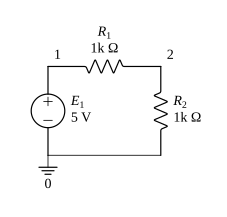

In [3]:
c1 = '''
e1,1,0,5
r1,1,2,1'k
r2,2,0,1'k
'''
draw(c1)

In [4]:
r1 = dc(c1)
r1

Result(domain='dc')
  i_e1 = -1/400
  i_r1 = 1/400
  i_r2 = 1/400
  p_e1 = -1/80
  p_r1 = 1/160
  p_r2 = 1/160
  r_e1 = 2000
  v_1 = 5
  v_2 = 5/2
  v_e1 = 5
  v_r1 = 5/2
  v_r2 = 5/2

## 2. Resistive ladder (DC)

The tutorial's first circuit, from Lesson 1: a series ladder in DC. Find the voltage at each node and the current, voltage and power of each element — sixteen answers from four lines.

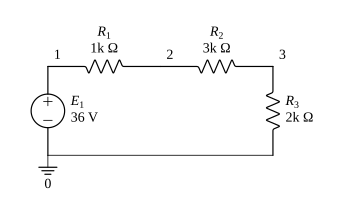

In [5]:
c2 = '''
e1,1,0,36
r1,1,2,1'k
r2,2,3,3'k
r3,3,0,2'k
'''
draw(c2)

In [6]:
r2 = dc(c2)
r2

Result(domain='dc')
  i_e1 = -3/500
  i_r1 = 3/500
  i_r2 = 3/500
  i_r3 = 3/500
  p_e1 = -27/125
  p_r1 = 9/250
  p_r2 = 27/250
  p_r3 = 9/125
  r_e1 = 6000
  v_1 = 36
  v_2 = 30
  v_3 = 12
  v_e1 = 36
  v_r1 = 6
  v_r2 = 18
  v_r3 = 12

## 3. Series RLC (AC, w=1000)

An AC (phasor) solve: a series RLC at 1000 rad/s. The answers are complex; tick 'Show AC answers as polar phasors' in Settings to read them as amplitude and angle.

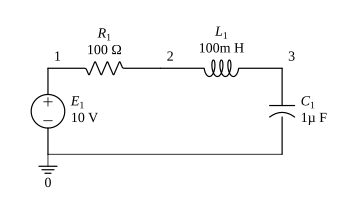

In [7]:
c3 = '''
e1,1,0,10
r1,1,2,100
l1,2,3,0.1
c1,3,0,1e-6
'''
draw(c3)

In [8]:
r3 = ac(c3, omega=1000)
r3

Result(domain='ac')
  ap_e1 = -0.00609756097560976
  ap_r1 = 0.00609756097560976
  i_c1 = 0.00121951219512195 + 0.0109756097560976*I
  i_e1 = -0.00121951219512195 - 0.0109756097560976*I
  i_l1 = 0.00121951219512195 + 0.0109756097560976*I
  i_r1 = 0.00121951219512195 + 0.0109756097560976*I
  p_e1 = -0.00609756097560976
  p_r1 = 0.00609756097560976
  q_e1 = 0.0548780487804878
  q_r1 = 0
  s_c1 = -0.0609756097560976*I
  s_e1 = -0.00609756097560976 + 0.0548780487804878*I
  s_l1 = 0.00609756097560976*I
  s_r1 = 0.00609756097560976
  v_1 = 10.0000000000000
  v_2 = 9.87804878048781 - 1.09756097560976*I
  v_3 = 10.9756097560976 - 1.21951219512195*I
  v_c1 = 10.9756097560976 - 1.21951219512195*I
  v_e1 = 10.0000000000000
  v_l1 = -1.09756097560976 + 0.121951219512195*I
  v_r1 = 0.121951219512194 + 1.09756097560976*I
  z_e1 = 100.0 - 900.0*I

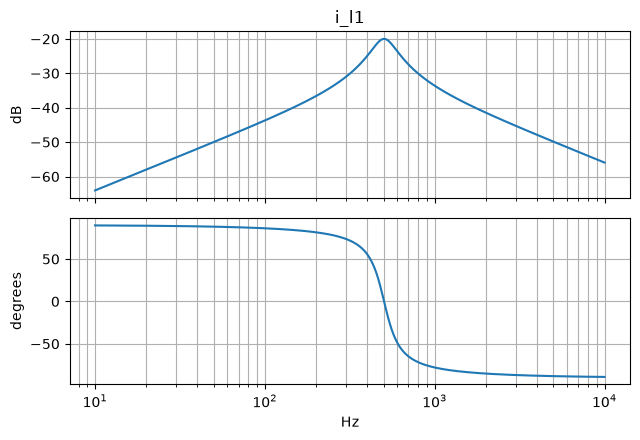

In [9]:
f, mag, phase = bode_samples(c3, 'i_l1', 10, 10000, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l1'); plt.tight_layout()

## 4. RC step response (TR)

A transient analysis: the classic RC charging curve. The limited-results box asks for just v_2, which comes back 5 - 5e^(-1000t).

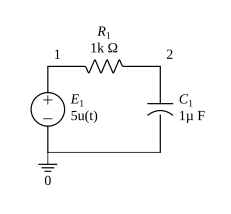

In [10]:
c4 = '''
e1,1,0,5*u(t)
r1,1,2,1000
c1,2,0,1e-6
'''
draw(c4)

In [11]:
r4 = tr(c4, variables=['v_2'])
r4

Result(domain='tr')
  v_2 = 5.0 - 5.0*exp(-1000.0*t)

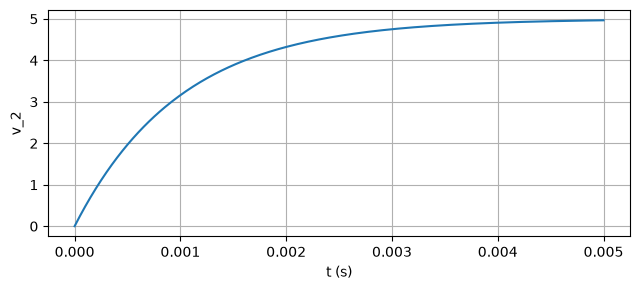

In [12]:
ts, ys = time_samples(c4, 'v_2', 0.005, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_2'); plt.grid(True); plt.tight_layout()

## 5. RL discharge, I0 = 3A (TR)

A transient with an initial condition: the inductor starts at 3 A (the fifth field of its description) and discharges through the resistor. i_l1 decays exponentially.

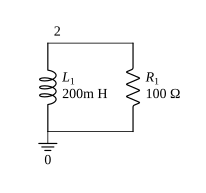

In [13]:
c5 = '''
l1,0,2,0.2,3
r1,2,0,100
'''
draw(c5)

In [14]:
r5 = tr(c5, variables=['i_l1'])
r5

Result(domain='tr')
  i_l1 = 3.0*exp(-500.0*t)

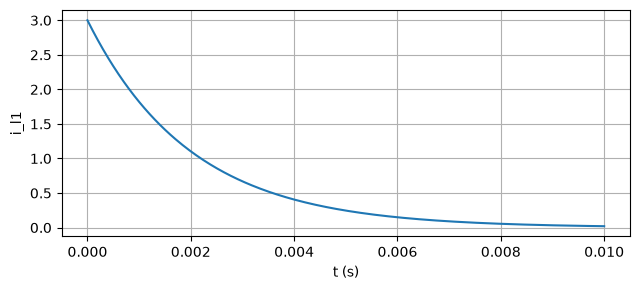

In [15]:
ts, ys = time_samples(c5, 'i_l1', 0.01, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l1'); plt.grid(True); plt.tight_layout()

## 6. Fully symbolic divider (DC)

What sets Symbulator apart: no numbers at all. The answers are formulas — v_2 comes back vin*r_b/(r_a + r_b), the voltage divider you would write by hand.

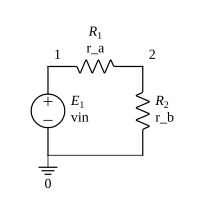

In [16]:
c6 = '''
e1,1,0,vin
r1,1,2,r_a
r2,2,0,r_b
'''
draw(c6)

In [17]:
r6 = dc(c6)
r6

Result(domain='dc')
  i_e1 = -vin/(r_a + r_b)
  i_r1 = vin/(r_a + r_b)
  i_r2 = vin/(r_a + r_b)
  p_e1 = -vin**2/(r_a + r_b)
  p_r1 = r_a*vin**2/(r_a + r_b)**2
  p_r2 = r_b*vin**2/(r_a + r_b)**2
  r_e1 = r_a + r_b
  v_1 = vin
  v_2 = r_b*vin/(r_a + r_b)
  v_e1 = vin
  v_r1 = r_a*vin/(r_a + r_b)
  v_r2 = r_b*vin/(r_a + r_b)

## 7. Inverting op-amp, gain -4 (DC)

An ideal op amp (the o element): the inverting amplifier with rf/rin = 4, so the 2 V input comes out as -8 V at node 3.

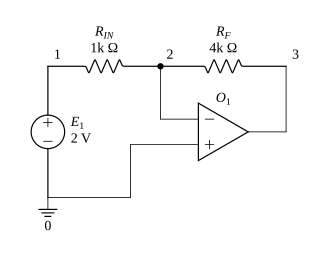

In [18]:
c7 = '''
e1,1,0,2
rin,1,2,1'k
rf,2,3,4'k
o1,0,2,3
'''
draw(c7)

In [19]:
r7 = dc(c7)
r7

Result(domain='dc')
  i_e1 = -1/500
  i_o1 = -1/500
  i_rf = 1/500
  i_rin = 1/500
  p_e1 = -1/250
  p_o1 = -2/125
  p_rf = 2/125
  p_rin = 1/250
  r_e1 = 1000
  v_1 = 2
  v_2 = 0
  v_3 = -8
  v_e1 = 2
  v_rf = 8
  v_rin = 2

## 8. Thevenin equivalent at node 2 (tool)

The Find equivalent analysis: the Thévenin / Norton equivalent seen from node 2 — vth, ino, req and pmax arrive together.

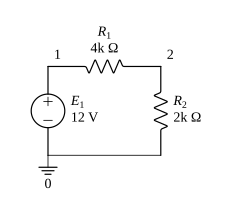

In [20]:
c8 = '''
e1,1,0,12
r1,1,2,4'k
r2,2,0,2'k
'''
draw(c8)

In [21]:
r8 = th(c8, '2', '0', domain='dc')
r8

TheveninResult(domain='dc', vth=4, ino=3/1000, req=4000/3, pmax=3/1000)

## 9. Two-port z parameters of a T network (tool)

Another equivalent: the z parameters of a T network between nodes 1 and 2, four numbers that stand in for the whole network.

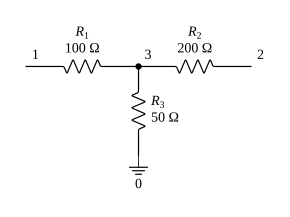

In [22]:
c9 = '''
r1,1,3,100
r2,2,3,200
r3,3,0,50
'''
draw(c9)

In [23]:
r9 = port(c9, '1', '2', 'z', domain='dc')
r9

PortResult('z', 11=150, 12=50, 21=50, 22=250)

## 10. Design: find r_b so that v2 = 6 V (expert)

Expert Mode: r_b is unknown, and the fact v_2 = 6 is handed over before solving, so the whole circuit comes back numerical — including the r_b that makes it true.

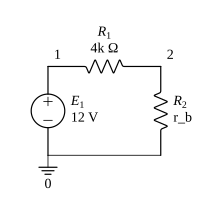

In [24]:
c10 = '''
e1,1,0,12
r1,1,2,4'k
r2,2,0,r_b
'''
draw(c10)

In [25]:
r10 = dc(c10, equations=['v_2 = 6'], unknowns=['r_b'])
r10

Result(domain='dc')
  i_e1 = -3/2000
  i_r1 = 3/2000
  i_r2 = 3/2000
  p_e1 = -9/500
  p_r1 = 9/1000
  p_r2 = 9/1000
  r_b = 4000
  r_e1 = 8000
  v_1 = 12
  v_2 = 6
  v_e1 = 12
  v_r1 = 6
  v_r2 = 6

## 11. RC step response, plotted (plot vs. time)

The Plot card: the RC charging curve of v_2 drawn against time, from 0 to 5 ms.

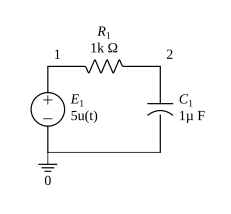

In [26]:
c11 = '''
e1,1,0,5*u(t)
r1,1,2,1'k
c1,2,0,1'u
'''
draw(c11)

In [27]:
r11 = tr(c11)
r11

Result(domain='tr')
  i_c1 = exp(-1000*t)/200
  i_e1 = -exp(-1000*t)/200
  i_r1 = exp(-1000*t)/200
  v_1 = 5
  v_2 = 5 - 5*exp(-1000*t)

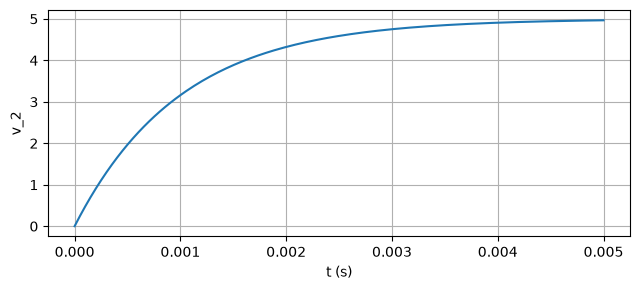

In [28]:
ts, ys = time_samples(c11, 'v_2', 0.005, t_min=0, n=200)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_2'); plt.grid(True); plt.tight_layout()

## 12. RC low-pass, Bode plot

The Bode plot: gain and phase of v_2 swept from 10 Hz to 100 kHz — flat, then falling 20 dB per decade past the corner, with the phase heading for -90°.

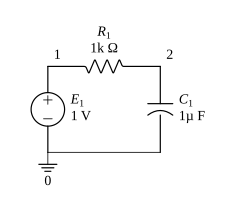

In [29]:
c12 = '''
e1,1,0,1
r1,1,2,1'k
c1,2,0,1'u
'''
draw(c12)

In [30]:
r12 = fd(c12)
r12

Result(domain='fd')
  i_c1 = s/(1000*(s + 1000))
  i_e1 = -s/(1000*s + 1000000)
  i_r1 = s/(1000*(s + 1000))
  v_1 = 1
  v_2 = 1000/(s + 1000)

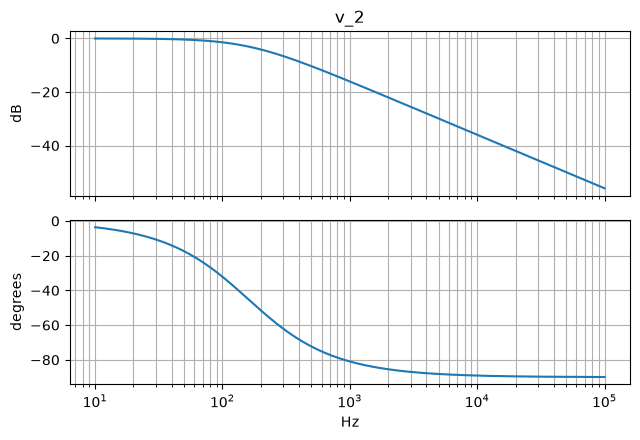

In [31]:
f, mag, phase = bode_samples(c12, 'v_2', 10, 100000, n=200)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('v_2'); plt.tight_layout()